In [112]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
subscribers_df = pd.read_csv ('subscribers.csv')
subscribers_df.columns

Index(['user_id', 'age', 'gender', 'state', 'city_tier', 'registration_date',
       'subscription_plan', 'monthly_price_inr', 'primary_device',
       'acquisition_channel', 'num_profiles', 'language_preference',
       'auto_renewal', 'churned', 'churn_date'],
      dtype='object')

In [3]:
watch_history_df = pd.read_csv('watch_history.csv')
watch_history_df.duplicated().sum()

0

In [4]:
payments_df = pd.read_csv('payments.csv')
payments_df.head()

,payment_id,user_id,payment_date,amount_inr,payment_method,payment_status,plan_at_payment
0,PAY5170401,USR000001,28-06-22,499,UPI,Success,Standard
1,PAY4682411,USR000001,28-07-22,499,Credit Card,Success,Standard
2,PAY1540771,USR000001,27-08-22,499,Net Banking,Success,Standard
3,PAY5120394,USR000001,26-09-22,499,UPI,Success,Standard
4,PAY7478286,USR000001,26-10-22,499,UPI,Success,Standard


In [5]:
support_tickets_df = pd.read_csv('support_tickets.csv')
support_tickets_df.duplicated().sum()

0

In [6]:
subscribers_df.value_counts().unique()

array([1], dtype=int64)

In [7]:
subscribers_df.isnull().sum()

user_id                    0
age                        0
gender                     0
state                      0
city_tier                  0
registration_date          0
subscription_plan          0
monthly_price_inr          0
primary_device             0
acquisition_channel        0
num_profiles               0
language_preference        0
auto_renewal               0
churned                    0
churn_date             10924
dtype: int64

In [8]:
subscribers_df.dtypes #change the datatypes 

user_id                object
age                     int64
gender                 object
state                  object
city_tier              object
registration_date      object
subscription_plan      object
monthly_price_inr       int64
primary_device         object
acquisition_channel    object
num_profiles            int64
language_preference    object
auto_renewal            int64
churned                 int64
churn_date             object
dtype: object

### TASKS TO PERFORM [FOR REFERENCE PURPOSES ONLY]  
SUBSCIBERS_DF 
1. churn_date is null is intentional then flag is as active users in the status column 
1. derive days_Active : churn_date - registration_date 
2. derive tenure_bucket : 30-60-90 days of activity + 


WATCH_HISTORY_DF 
1. watch_Date convert to datetime 


PAYMENTS_DF 
1. payment_date convert to datetime 
2. payment_status : check for any inconsistentencies 
3. derive a payment failed flag 1/0 

SUPPORT TICKET DF 
1. ticket_date convert to datetime 
2. resolution status check casing consistency 
3. response time in hours : check for integer should have no outliers beyond 72 hours 

In [10]:
subscribers_df['registration_date'] = pd.to_datetime(subscribers_df['registration_date'], format='%Y-%m-%d').dt.date

In [11]:
print(type(subscribers_df['registration_date'][0]))

<class 'datetime.date'>


In [12]:
subscribers_df['churn_date'] = pd.to_datetime(subscribers_df['churn_date'], format='mixed').dt.date

In [13]:
print(type(subscribers_df['churn_date'][0]))

<class 'pandas._libs.tslibs.nattype.NaTType'>


In [14]:
subscribers_df['days_active'] = (
    pd.to_datetime(subscribers_df['churn_date'])
    .fillna(pd.Timestamp('2024-12-31'))        # active users ka proxy end date
    - pd.to_datetime(subscribers_df['registration_date'])
).dt.days #creation of the days active column using the difference between churn_date and registration_date 

In [15]:
print(subscribers_df[['registration_date', 'churn_date', 'days_active']].head(10))

  registration_date churn_date  days_active
0        2022-06-28        NaT          917
1        2023-07-24        NaT          526
2        2023-06-26        NaT          554
3        2022-04-04        NaT         1002
4        2022-05-27        NaT          949
5        2023-04-15        NaT          626
6        2022-10-20        NaT          803
7        2022-07-06        NaT          909
8        2022-01-24        NaT         1072
9        2024-10-22        NaT           70


In [16]:
print(subscribers_df[subscribers_df['churned'] == 1][['registration_date', 'churn_date', 'days_active']].head(10))
#counting the number of days they were active who ultimately churned out 

   registration_date  churn_date  days_active
13        2023-03-28  2024-04-23          392
15        2022-05-05  2022-11-24          203
16        2022-07-20  2023-05-22          306
18        2023-10-05  2024-08-29          329
19        2024-04-06  2024-12-31          269
23        2023-12-04  2024-11-22          354
24        2023-06-21  2024-03-03          256
27        2023-07-01  2024-07-24          389
36        2024-07-23  2024-12-31          161
42        2023-01-08  2023-08-20          224


In [17]:
def tenure_bucket(days):
    if days <= 90:
        return '0-3 Months'
    elif days <=180:
        return '3-6 Months'
    elif days <=365:
        return '6-12 Months'
    else:
        return '12+ Months'

subscribers_df ['tenure_bucket'] = subscribers_df['days_active'].apply(tenure_bucket)
#showing exactly how many months were the users active using buckets 

In [18]:
print(subscribers_df['tenure_bucket'].value_counts())

tenure_bucket
12+ Months     8174
6-12 Months    3365
3-6 Months     1774
0-3 Months     1687
Name: count, dtype: int64


In [19]:
# we have boolean values of either 0 or 1 for churned who do not convery any meaning as of now . so lets 
# categorize them into active or churned 

subscribers_df['subscriber_status'] = np.where(subscribers_df['churned']==1,'Churned','Active')

In [20]:
subscribers_df

,user_id,age,gender,state,city_tier,registration_date,subscription_plan,monthly_price_inr,primary_device,acquisition_channel,num_profiles,language_preference,auto_renewal,churned,churn_date,days_active,tenure_bucket,subscriber_status
0,USR000001,24,Male,Karnataka,Tier 1,2022-06-28,Standard,499,Mobile,Social Media,2,Marathi,1,0,NaT,917,12+ Months,Active
1,USR000002,55,Male,Karnataka,Tier 3,2023-07-24,Mobile,149,Smart TV,Referral,4,English,1,0,NaT,526,12+ Months,Active
2,USR000003,40,Female,Maharashtra,Tier 2,2023-06-26,Premium,799,Mobile,Organic Search,4,Hindi,1,0,NaT,554,12+ Months,Active
3,USR000004,22,Female,Karnataka,Tier 3,2022-04-04,Standard,499,Tablet,Social Media,2,Bengali,1,0,NaT,1002,12+ Months,Active
4,USR000005,35,Male,Delhi,Tier 2,2022-05-27,Basic,299,Laptop,Social Media,2,English,1,0,NaT,949,12+ Months,Active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,USR014996,31,Female,Madhya Pradesh,Tier 3,2024-07-29,Mobile,149,Laptop,Social Media,3,Tamil,1,1,2024-12-31,155,3-6 Months,Churned
14996,USR014997,41,Male,Maharashtra,Tier 2,2023-07-12,Standard,499,Laptop,Social Media,4,English,0,0,NaT,538,12+ Months,Active
14997,USR014998,48,Female,Telangana,Tier 3,2023-03-24,Mobile,149,Laptop,Paid Ad,4,English,1,0,NaT,648,12+ Months,Active
14998,USR014999,53,Male,Karnataka,Tier 3,2024-11-23,Mobile,149,Tablet,Referral,2,Telugu,1,0,NaT,38,0-3 Months,Active


In [21]:
print(subscribers_df.columns.tolist())
print(subscribers_df.shape)

['user_id', 'age', 'gender', 'state', 'city_tier', 'registration_date', 'subscription_plan', 'monthly_price_inr', 'primary_device', 'acquisition_channel', 'num_profiles', 'language_preference', 'auto_renewal', 'churned', 'churn_date', 'days_active', 'tenure_bucket', 'subscriber_status']
(15000, 18)


In [22]:
print(watch_history_df.columns.tolist())
print(watch_history_df.shape)

['session_id', 'user_id', 'watch_date', 'genre', 'content_type', 'language_watched', 'watch_duration_mins', 'device_used', 'completed']
(862217, 9)


In [23]:
watch_history_df['watch_date'] = pd.to_datetime(watch_history_df['watch_date'], format='mixed').dt.date

In [24]:
print(type(watch_history_df['watch_date'][0]))

<class 'datetime.date'>


In [25]:
payments_df['payment_date'] = pd.to_datetime(payments_df['payment_date'],format='mixed').dt.date

In [26]:
print(type(payments_df['payment_date'][0]))

<class 'datetime.date'>


In [27]:
payments_df['payment_status'].value_counts().unique

<bound method Series.unique of payment_status
Success    206288
Failed      17192
Name: count, dtype: int64>

In [28]:
print(payments_df.columns.tolist())
print(payments_df.shape)

['payment_id', 'user_id', 'payment_date', 'amount_inr', 'payment_method', 'payment_status', 'plan_at_payment']
(223480, 7)


In [29]:
support_tickets_df['ticket_date'] = pd.to_datetime(support_tickets_df['ticket_date'],format='mixed').dt.date

In [30]:
print(type(support_tickets_df['ticket_date'][0]))

<class 'datetime.date'>


In [31]:
support_tickets_df['resolution_status'].value_counts()

resolution_status
Resolved      4867
Unresolved    2830
Escalated     1832
Name: count, dtype: int64

In [32]:
support_tickets_df['response_time_hrs'].value_counts().sum()

9529

In [33]:
# to check for any outliers i.e check if any of the response time in hours is more than 72 hours 

print(support_tickets_df[support_tickets_df['response_time_hrs'] > 72].shape)

(0, 6)


# Data Visualizations 

C:\Users\Rajashri\AppData\Local\Temp\ipykernel_10880\1789154398.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plan_churn.values, y=plan_churn.index, palette='Reds_r')


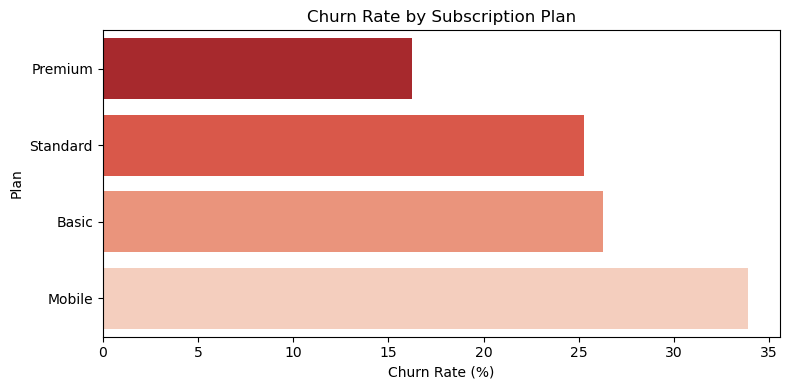

In [114]:
# Visual 1 : Churn Rate by Subscription Plan 
# Business Question : Which plan has the highest churn ? 

plan_churn = subscribers_df.groupby('subscription_plan')['churned'].mean().sort_values()*100
plt.figure(figsize=(8,4))
sns.barplot(x=plan_churn.values, y=plan_churn.index, palette='Reds_r')
plt.title ('Churn Rate by Subscription Plan')
plt.xlabel ('Churn Rate (%)')
plt.ylabel ('Plan')
plt.tight_layout()
plt.show()

C:\Users\Rajashri\AppData\Local\Temp\ipykernel_10880\3106825126.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_churn.values, y=channel_churn.index , palette ='Blues_r')


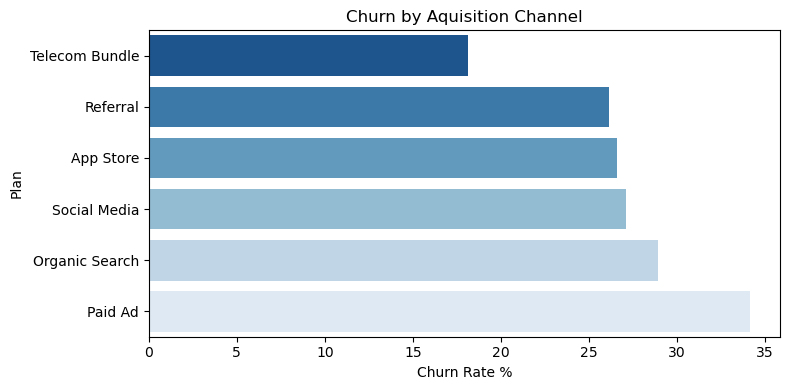

In [116]:
# Visual 2 : Churn Rate by Acquisition Channel 
# Business Question : Which channel brings most of the loyal users ? 

channel_churn = subscribers_df.groupby('acquisition_channel')['churned'].mean().sort_values()*100
plt.figure(figsize=(8,4))
sns.barplot(x=channel_churn.values, y=channel_churn.index , palette ='Blues_r')
plt.title ('Churn by Aquisition Channel')
plt.xlabel('Churn Rate %')
plt.ylabel ('Plan')
plt.tight_layout()
plt.show()

C:\Users\Rajashri\AppData\Local\Temp\ipykernel_10880\2563126004.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tenure_churn.index, y=tenure_churn.values, palette='Oranges_r')


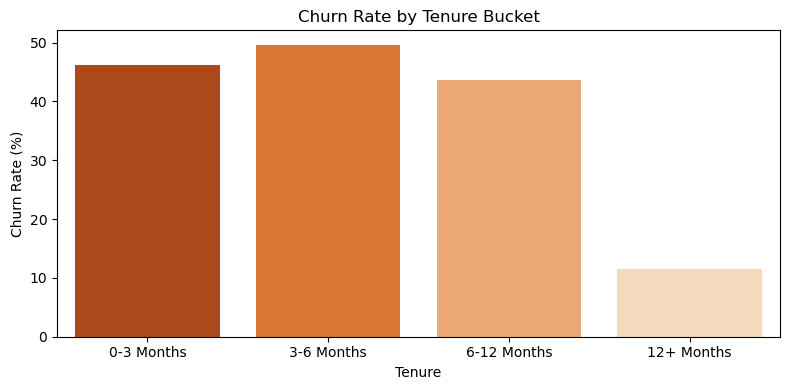

In [120]:
# Visual 3 : Churn Rate by Tenure Bucket
# Business Question: At what stage of their lifecycle do users churn the most?

tenure_order = ['0-3 Months', '3-6 Months', '6-12 Months', '12+ Months']
tenure_churn = subscribers_df.groupby('tenure_bucket')['churned'].mean().reindex(tenure_order) * 100

plt.figure(figsize=(8,4))
sns.barplot(x=tenure_churn.index, y=tenure_churn.values, palette='Oranges_r')
plt.title('Churn Rate by Tenure Bucket')
plt.xlabel('Tenure')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

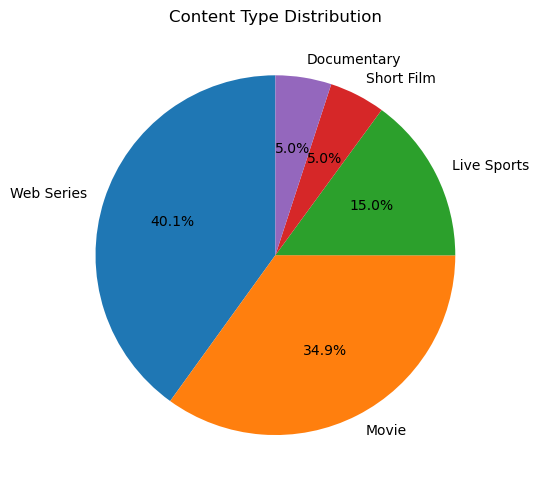

In [124]:
# Visual 4 : Content Type Distribution
# Business Question: What type of content do our users watch the most?

content_counts = watch_history_df['content_type'].value_counts()

plt.figure(figsize=(7,5))
plt.pie(content_counts.values, labels=content_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Content Type Distribution')
plt.tight_layout()
plt.show()

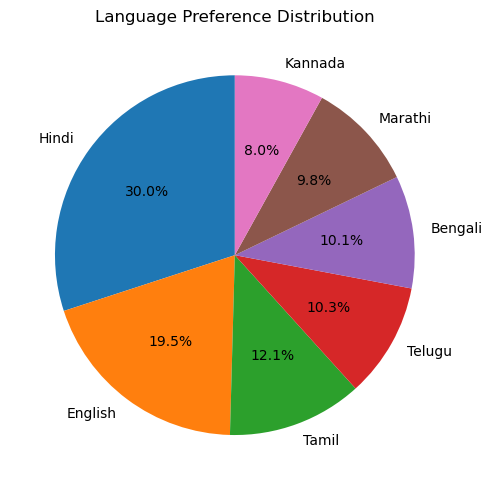

In [126]:
# Visual 5 : Language Preference Distribution
# Business Question: Which language content is consumed the most?

lang_counts = subscribers_df['language_preference'].value_counts()

plt.figure(figsize=(7,5))
plt.pie(lang_counts.values, labels=lang_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Language Preference Distribution')
plt.tight_layout()
plt.show()

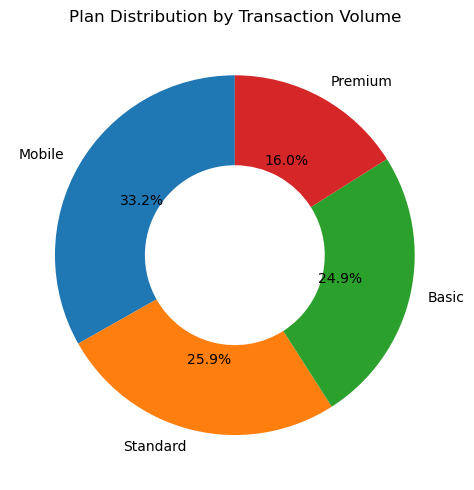

In [130]:
# Visual 6 : Most Purchased Plan by Transaction Volume
# Business Question: Which plan drives the most payment transactions?

plan_counts = payments_df['plan_at_payment'].value_counts()

plt.figure(figsize=(7,5))
wedges, texts, autotexts = plt.pie(plan_counts.values, labels=plan_counts.index, 
                                    autopct='%1.1f%%', startangle=90,
                                    wedgeprops=dict(width=0.5))
plt.title('Plan Distribution by Transaction Volume')
plt.tight_layout()
plt.show()

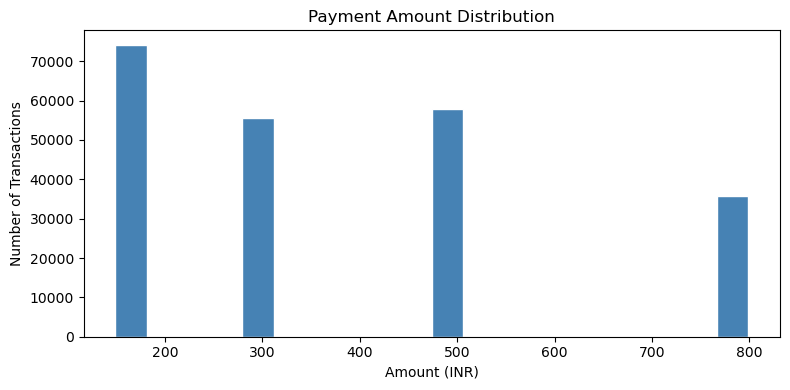

In [137]:
# Visual 7 : Payment Amount Distribution
# Business Question: What price points are most common across all transactions?

plt.figure(figsize=(8,4))
plt.hist(payments_df['amount_inr'], bins=20, color='steelblue', edgecolor='white')
plt.title('Payment Amount Distribution')
plt.xlabel('Amount (INR)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

### Done with the data cleaning ! Now lets export all the dataframes ! 

In [ ]:
# 1ST DATAFRAME 

subscribers_df.to_csv('subscribers_cleaned.csv', index = False)

In [ ]:
# 2ND DATAFRAME 

watch_history_df.to_csv('watch_history_cleaned.csv',index = False)

In [ ]:
# 3RD DATAFRAME 

payments_df.to_csv('payments_cleaned.csv',index=False)

In [ ]:
#4TH DATAFRAME 

support_tickets_df.to_csv('support_tickets_cleaned.csv',index = False)

# END OF EXPLORATORY DATA ANALYSIS : OTT CHURN DATA ! 